# Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyinform.utils import coalesce_series, coalesce
from pyinform import transfer_entropy
import networkx as nx
from scipy import stats
import sys
print(sys.executable)

c:\Users\taoni\Documents\jc\venv\Scripts\python.exe


### Load data

In [2]:
data = np.genfromtxt("data_allplanes.csv", delimiter=",")

# 1 Data normalization

[  5.21560352   6.09997621  13.02125436 ...  34.0496583  -12.15346486
  17.27890364]


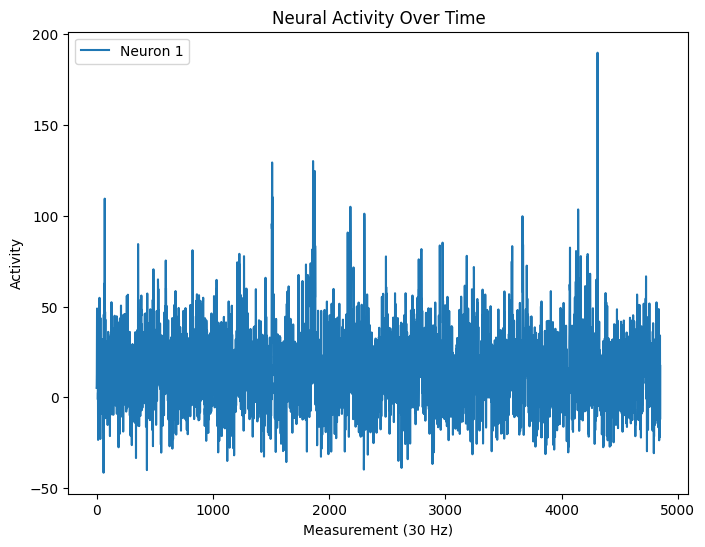

In [3]:
# Neuronal activity for neuron 1
print(data[0])

# Plot data for neuron 1
plt.figure(figsize=(8, 6))
plt.plot(np.arange(0, data.shape[1]), data[0,:], label="Neuron 1")
# plt.plot(np.arange(0, data.shape[1]), data[1,:], label="Neuron 2")
# plt.plot(np.arange(0, data.shape[1]), data[2,:], label="Neuron 3")
# plt.plot(np.arange(0, data.shape[1]), data[3,:], label="Neuron 4")
# plt.plot(np.arange(0, data.shape[1]), data[4,:], label="Neuron 5")

plt.xlabel("Measurement (30 Hz)")
plt.ylabel("Activity")
plt.title("Neural Activity Over Time")
plt.legend()
plt.show()

In [4]:
# Relative change normalization (deltaF/F0)
window_size = 300
n_neurons, n_frames = data.shape

norm_data = np.zeros_like(data, dtype=float)

for i in range(n_neurons):
# for i in range(1):
    neuron = data[i]
    for t in range(n_frames):
        start = max(0, t - window_size)
        if t == 0:
            F0 = neuron[0]
        else:
            window = neuron[start:t]
            if window.size <= 1:
                F0 = neuron[0]
            else:
                median = np.percentile(window, 50)
                lower_half = window[window < median]
                F0 = np.mean(lower_half)
        if F0 == 0:
            F0 = 1e-6
        norm_data[i, t] = (neuron[t] - F0) / F0
    if i % 10 == 0:
        print(f"Neuron {i+1} normalized")

Neuron 1 normalized
Neuron 11 normalized
Neuron 21 normalized
Neuron 31 normalized
Neuron 41 normalized
Neuron 51 normalized
Neuron 61 normalized
Neuron 71 normalized
Neuron 81 normalized
Neuron 91 normalized
Neuron 101 normalized
Neuron 111 normalized
Neuron 121 normalized
Neuron 131 normalized
Neuron 141 normalized
Neuron 151 normalized
Neuron 161 normalized
Neuron 171 normalized
Neuron 181 normalized
Neuron 191 normalized
Neuron 201 normalized
Neuron 211 normalized
Neuron 221 normalized
Neuron 231 normalized
Neuron 241 normalized
Neuron 251 normalized
Neuron 261 normalized
Neuron 271 normalized
Neuron 281 normalized
Neuron 291 normalized
Neuron 301 normalized
Neuron 311 normalized
Neuron 321 normalized
Neuron 331 normalized
Neuron 341 normalized
Neuron 351 normalized
Neuron 361 normalized
Neuron 371 normalized
Neuron 381 normalized
Neuron 391 normalized
Neuron 401 normalized
Neuron 411 normalized
Neuron 421 normalized
Neuron 431 normalized
Neuron 441 normalized
Neuron 451 normalized

In [8]:
# Write norm_data to csv
np.savetxt("norm_data.csv", norm_data, delimiter=",")

# Read norm_data from csv
# norm_data = np.genfromtxt("norm_data.csv", delimiter=",")

# 2 Pearson correlation

### 2.1 Correlation matrix summary (plot and stats)

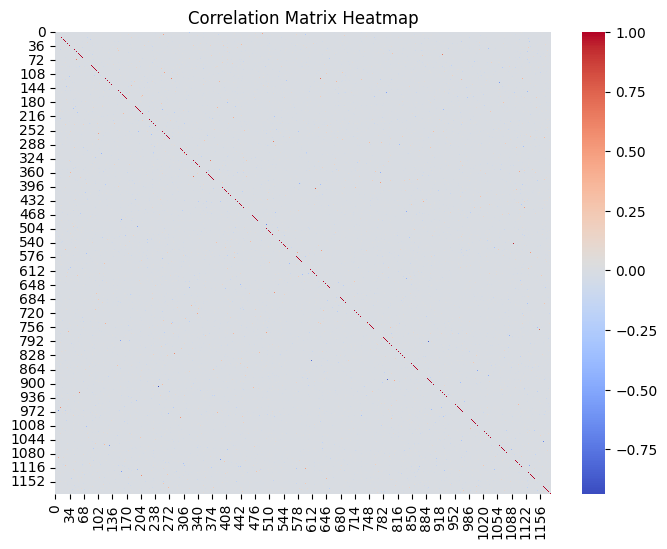

[[ 1.00000000e+00 -1.31250755e-03 -9.41155259e-04 ...  1.27393764e-03
  -3.82423505e-04  1.86799799e-04]
 [-1.31250755e-03  1.00000000e+00  3.88887914e-04 ... -3.02822747e-04
   8.00233500e-05  1.15381202e-03]
 [-9.41155259e-04  3.88887914e-04  1.00000000e+00 ...  3.75231986e-03
  -1.37481780e-03  2.25567453e-04]
 ...
 [ 1.27393764e-03 -3.02822747e-04  3.75231986e-03 ...  1.00000000e+00
   4.39743474e-03  4.08029587e-04]
 [-3.82423505e-04  8.00233500e-05 -1.37481780e-03 ...  4.39743474e-03
   1.00000000e+00 -3.12765742e-04]
 [ 1.86799799e-04  1.15381202e-03  2.25567453e-04 ...  4.08029587e-04
  -3.12765742e-04  1.00000000e+00]]
[1.72267608e-06 8.85773222e-07 3.46630130e-07 ... 1.93374323e-05
 1.66488144e-07 9.78224093e-08]
                R^2
count  6.991530e+05
mean   2.398117e-04
std    6.684266e-03
min    1.890320e-18
25%    1.389283e-07
50%    9.737213e-07
75%    6.904095e-06
max    9.754137e-01


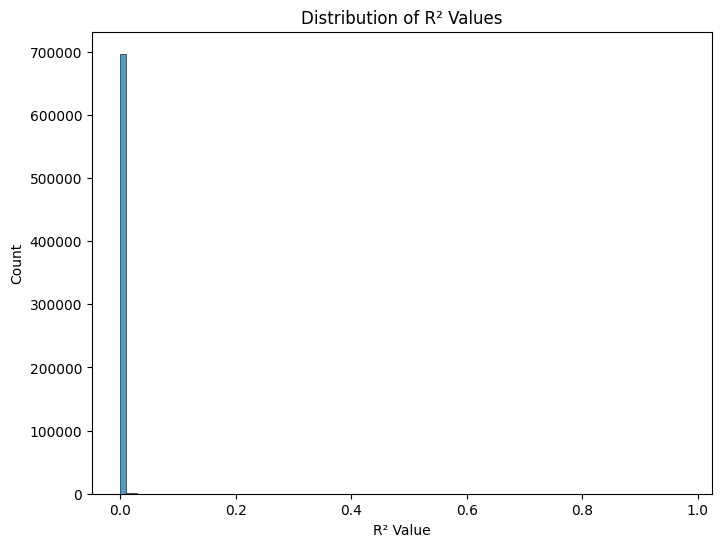

In [11]:
corr_matrix = np.corrcoef(norm_data)

# Plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Summary stats for r^2 values
corr_matrix = np.corrcoef(norm_data)
print(corr_matrix)
r2_vals = np.square(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
print(r2_vals)
df = pd.DataFrame(r2_vals, columns=['R^2'])
print(df.describe())

# Plot histogram of r^2 values
plt.figure(figsize=(8, 6))
sns.histplot(r2_vals, bins=100)
plt.xlabel('R² Value')
plt.title('Distribution of R² Values')
plt.show()

### 2.2 Thresholded correlation matrix

r > 0.00: 1398306 edges
r > 0.01: 84884 edges
r > 0.02: 35522 edges
r > 0.03: 21304 edges
r > 0.04: 14692 edges
r > 0.05: 11012 edges
r > 0.06: 8674 edges
r > 0.07: 6994 edges
r > 0.08: 5770 edges
r > 0.09: 4890 edges
r > 0.10: 4176 edges
r > 0.11: 3656 edges
r > 0.12: 3234 edges
r > 0.13: 2880 edges
r > 0.14: 2548 edges
r > 0.15: 2314 edges
r > 0.16: 2090 edges
r > 0.17: 1838 edges
r > 0.18: 1680 edges
r > 0.19: 1538 edges


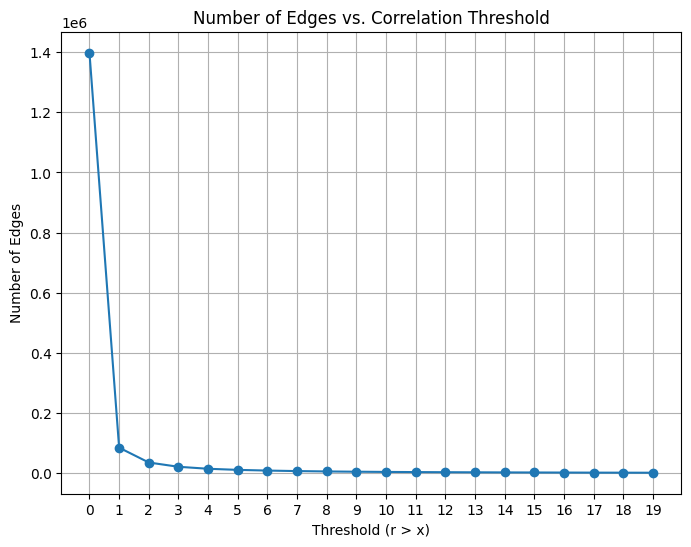

In [17]:
# Analyze correlation matrix with different thresholds
num_edges = np.zeros(20)
for i in range(0, 20):
    corr_matrix = np.corrcoef(norm_data)

    # Remove self-correlations
    np.fill_diagonal(corr_matrix, 0)

    # Threshold weak correlations
    threshold = 0.01 * i
    corr_matrix[np.abs(corr_matrix) < threshold] = 0

    # Create undirected weighted graph
    G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)

    print(f"r > {threshold:.2f}: {G.number_of_edges()} edges")
    num_edges[i] = G.number_of_edges()
    
plt.figure(figsize=(8, 6))
plt.plot(range(0, 20), num_edges, marker='o')
plt.xlabel('Threshold (r > x)')
plt.ylabel('Number of Edges')
plt.title('Number of Edges vs. Correlation Threshold')
plt.xticks(range(0, 20))
plt.grid()
plt.show()

In [18]:
# Threshold r > 0.1 and save graph
corr_matrix = np.corrcoef(norm_data)
np.fill_diagonal(corr_matrix, 0)
threshold = 0.1
corr_matrix[np.abs(corr_matrix) < threshold] = 0

# Create undirected weighted graph
G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)
pos = nx.spring_layout(G, seed=42)

# nx.draw(G, pos, node_color='skyblue', node_size=100)

# nx.draw_networkx_edges(G, pos, width=2, edge_color='black')

# plt.title(f"Thresholded Pearson Correlation Network (r > {threshold:.2f})")
# plt.show()

print(f"r > {threshold:.2f}: {G.number_of_edges()} edges")
nx.write_graphml(G, f"neurons{threshold*100:.0f}.graphml")

r > 0.10: 4176 edges


### 2.3 p-value analysis

In [13]:
# Output a matrix with calculated p-values for the correlation matrix
n_neurons = norm_data.shape[0]
p_matrix = np.ones((n_neurons, n_neurons))
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        if i != j:
            p_matrix[i, j] = stats.pearsonr(norm_data[i], norm_data[j])[1]
    if i % 10 == 0:
        print(f"Calculated p-values for neuron {i+1}")

    p_matrix[i, i] = 0  # self-comparison

Calculated p-values for neuron 1
Calculated p-values for neuron 11
Calculated p-values for neuron 21
Calculated p-values for neuron 31
Calculated p-values for neuron 41
Calculated p-values for neuron 51
Calculated p-values for neuron 61
Calculated p-values for neuron 71
Calculated p-values for neuron 81
Calculated p-values for neuron 91
Calculated p-values for neuron 101
Calculated p-values for neuron 111
Calculated p-values for neuron 121
Calculated p-values for neuron 131
Calculated p-values for neuron 141
Calculated p-values for neuron 151
Calculated p-values for neuron 161
Calculated p-values for neuron 171
